In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
#Setting up visual style
sns.set(style="whitegrid")
#loading the dataset
df = pd.read_csv(r"C:\Users\Elinam\Desktop\Projects\Python\2026 QS World University Rankings.csv")
# Initial observation
print(df.shape)
print(df.head)
print(df.info)
print(df.dtypes)
df.duplicated().sum()
print("Number of duplicate rows:", df.duplicated().sum())
print("\nMissing values per column:")
print(df.isnull().sum())
# Data Cleaning
df['Institution Name'] = df['Institution Name'].str.strip()
df['Country/Territory'] = df['Country/Territory'].str.strip()
df['Region'] = df['Region'].str.strip()
# Changing data types to appropraite data type
# Convert columns to appropriate types
text_cols = [
    "Institution Name", "Country/Territory", "Region", "Size",
    "Focus", "Research", "Status"
]

for col in text_cols:
    df[col] = df[col].astype("string")
# Convert numeric columns to appropriate types
rank_score_cols = [
    "2026 Rank", "Previous Rank", "AR RANK", "ER RANK", "FSR RANK", "CPF RANK",
    "IFR RANK", "ISR RANK", "ISD RANK", "IRN RANK", "EO RANK", "SUS RANK", "Overall SCORE"
]

# Clean and convert each column
for col in rank_score_cols:
    if col in df.columns:
        # Strip spaces, remove commas, replace dashes
        df[col] = df[col].astype(str).str.strip().str.replace(',', '', regex=False)
        df[col] = df[col].replace(['—', 'N/A', '', 'null'], pd.NA)
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
# Check data types after conversion
print(df.dtypes)
df.info()



(1501, 30)
<bound method NDFrame.head of      2026 Rank Previous Rank                             Institution Name  \
0            1             1  Massachusetts Institute of Technology (MIT)   
1            2             2                      Imperial College London   
2            3             6                          Stanford University   
3            4             3                         University of Oxford   
4            5             4                           Harvard University   
...        ...           ...                                          ...   
1496     1401+     1201-1400                   University of West Bohemia   
1497     1401+     1201-1400                    Voronezh State University   
1498     1401+           NaN                          Walailak University   
1499     1401+     1201-1400                         Yamaguchi University   
1500     1401+     1201-1400                          Youngsan University   

             Country/Territory    

C:\Users\Elinam\AppData\Local\Temp\ipykernel_14892\2907000245.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y="Institution Name", x="Overall SCORE", palette="viridis")
C:\Users\Elinam\AppData\Local\Temp\ipykernel_14892\2907000245.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=improved_unis, x="Rank Change", y="Institution Name", palette="YlGnBu")


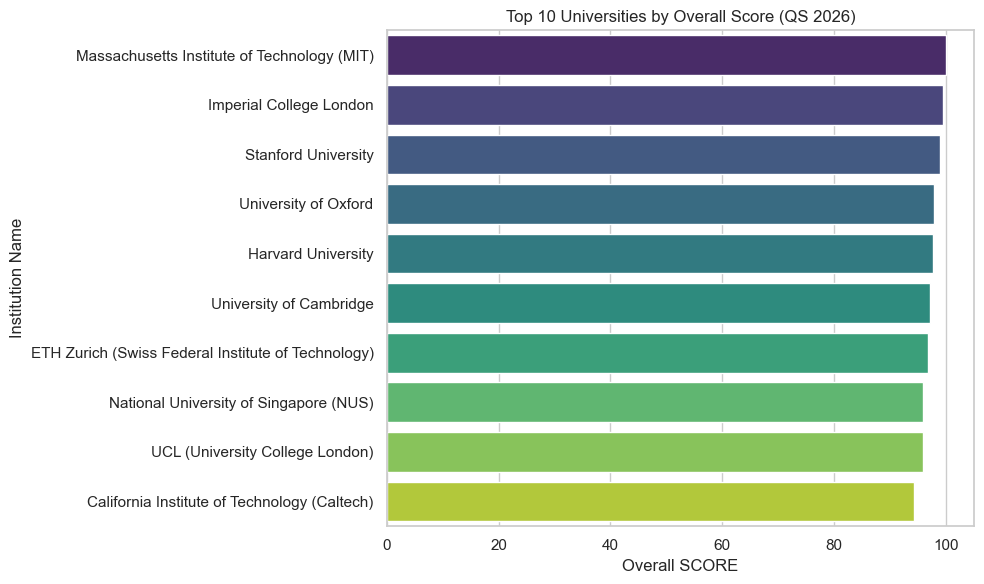

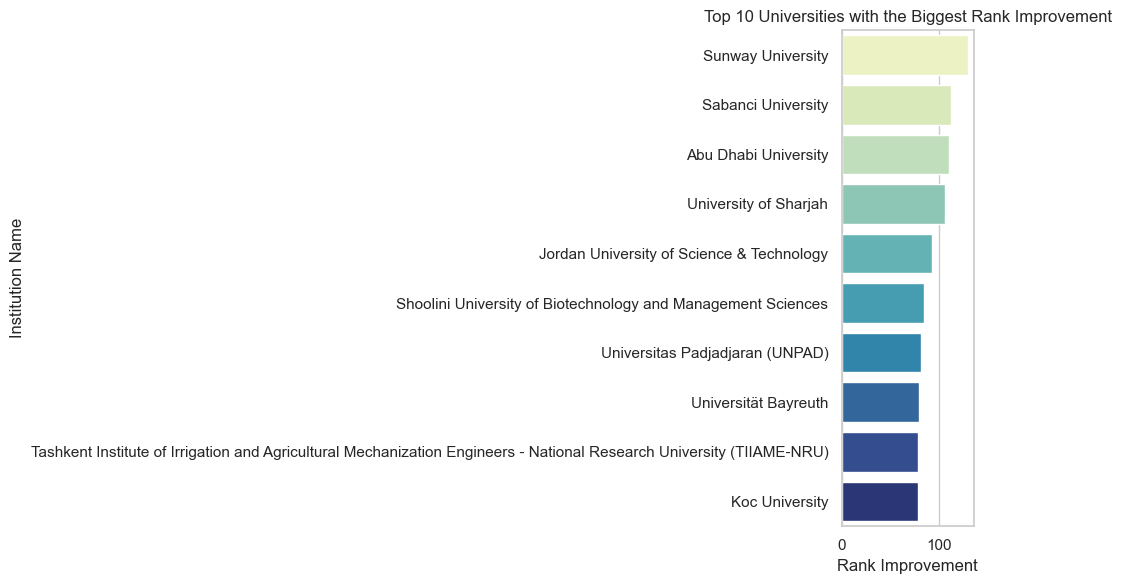

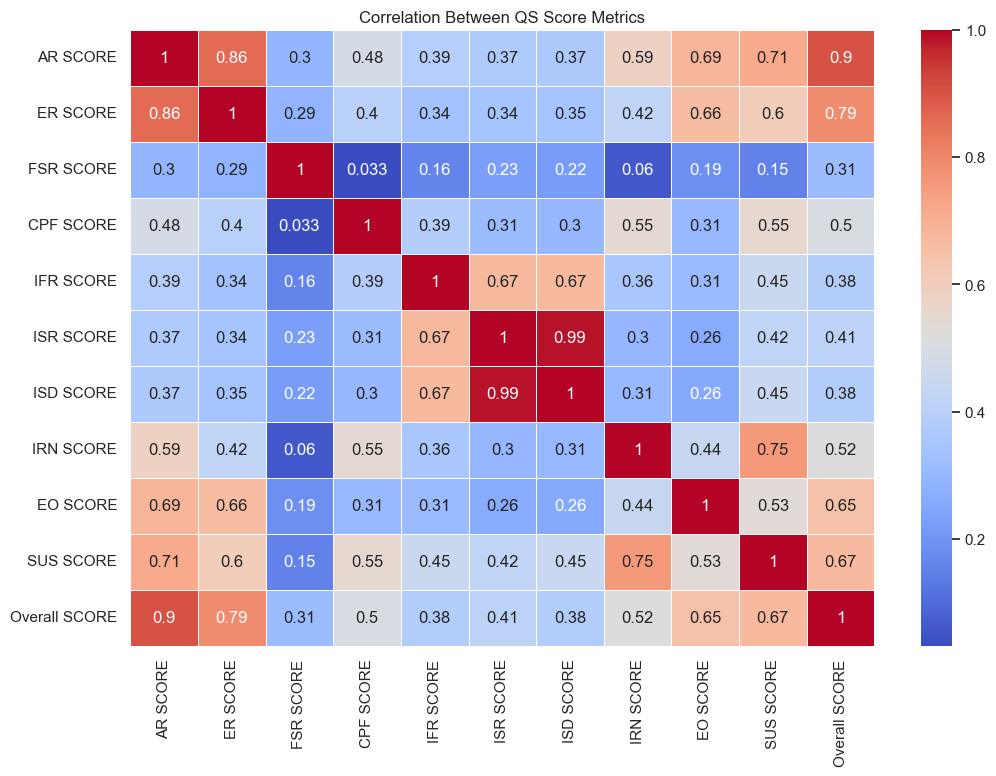

C:\Users\Elinam\AppData\Local\Temp\ipykernel_14892\2907000245.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_countries.index, x=top_countries.values, palette="coolwarm")
C:\Users\Elinam\AppData\Local\Temp\ipykernel_14892\2907000245.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Region", y="ISR SCORE", palette="Set1")
C:\Users\Elinam\AppData\Local\Temp\ipykernel_14892\2907000245.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Figure size 640x480 with 0 Axes>

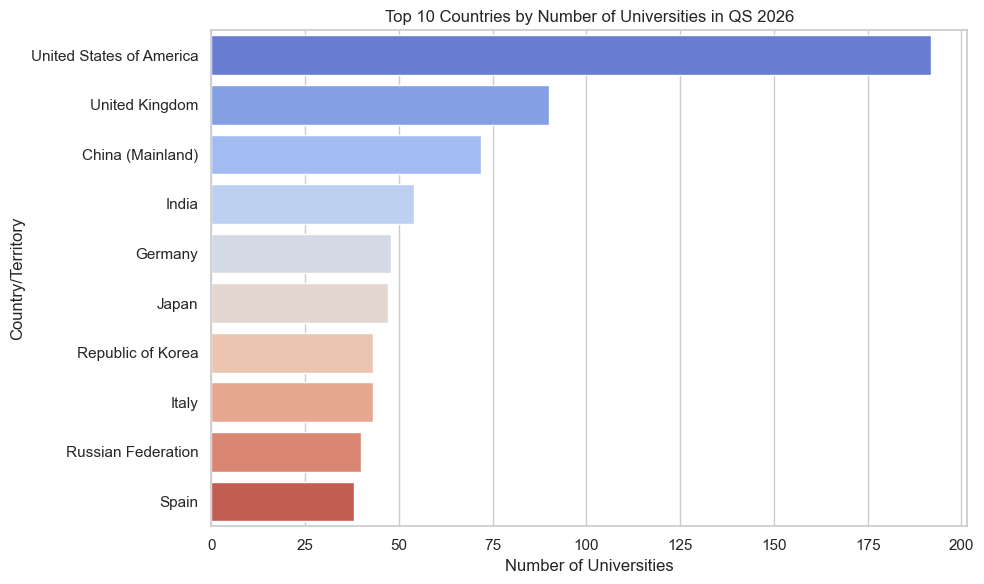

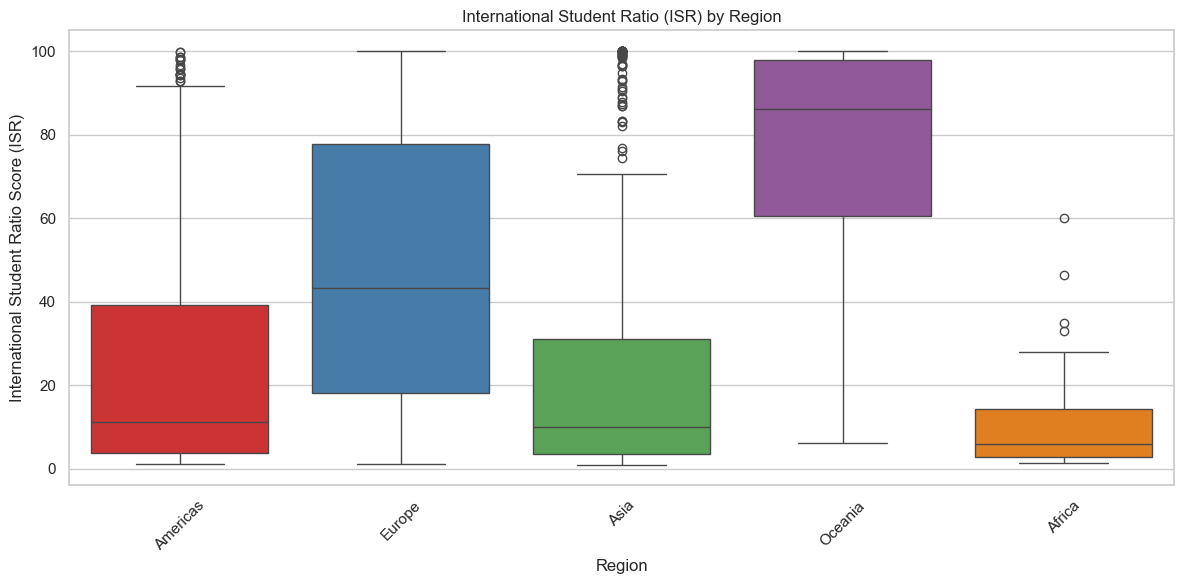

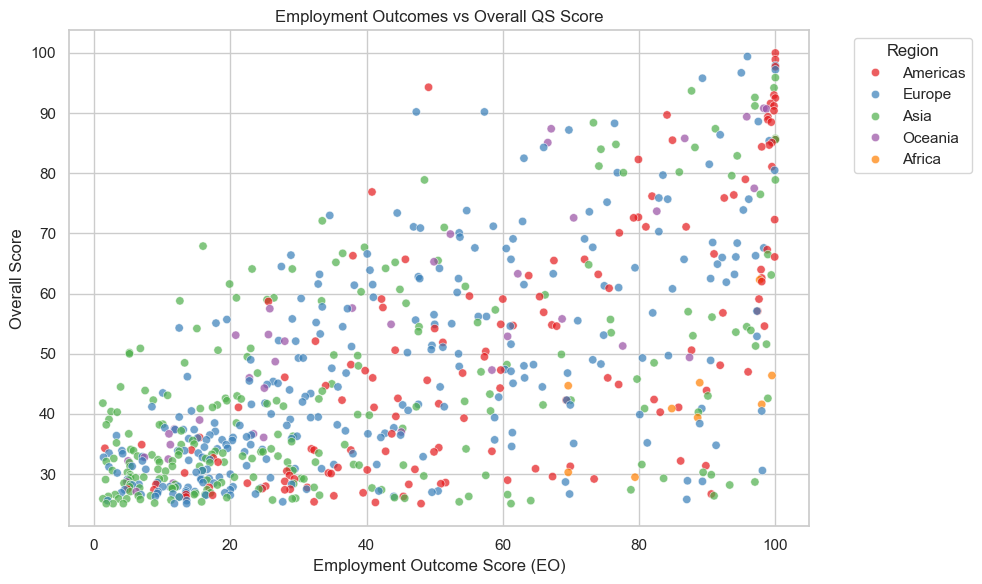

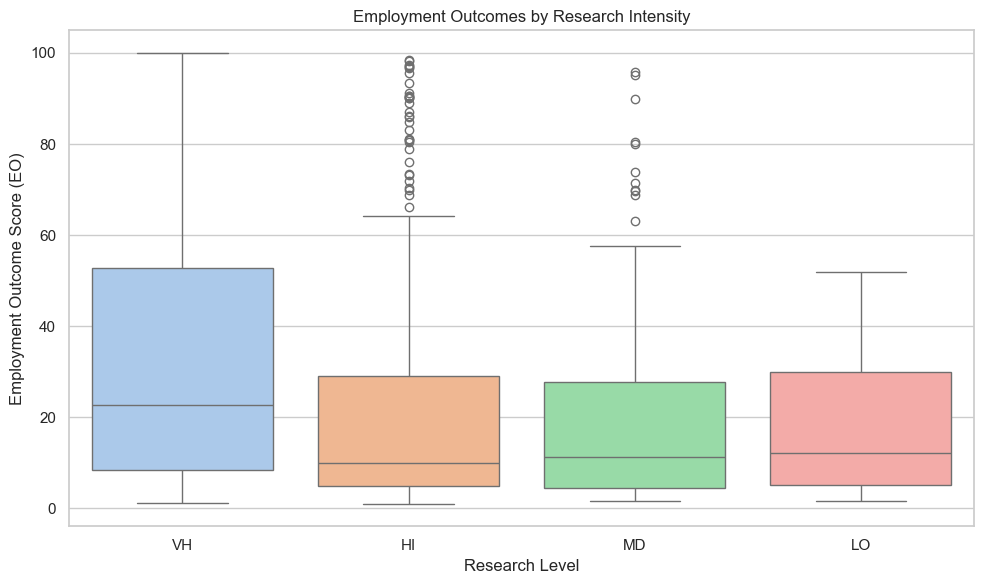


Top 10 Universities by Research Output (IRN SCORE):
                                      Institution Name  \
3                                 University of Oxford   
8                      UCL (University College London)   
27                                      PSL University   
33                             University of Edinburgh   
59                                           KU Leuven   
299                              Université Paris Cité   
4                                   Harvard University   
34                        The University of Manchester   
72   Sorbonne University (merged from Paris IV & UPMC)   
431                          Université de Montpellier   

            Country/Territory  IRN SCORE  
3              United Kingdom      100.0  
8              United Kingdom       99.9  
27                     France       99.7  
33             United Kingdom       99.5  
59                    Belgium       99.5  
299                    France       99.5  
4    Un

C:\Users\Elinam\AppData\Local\Temp\ipykernel_14892\2907000245.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Figure size 640x480 with 0 Axes>

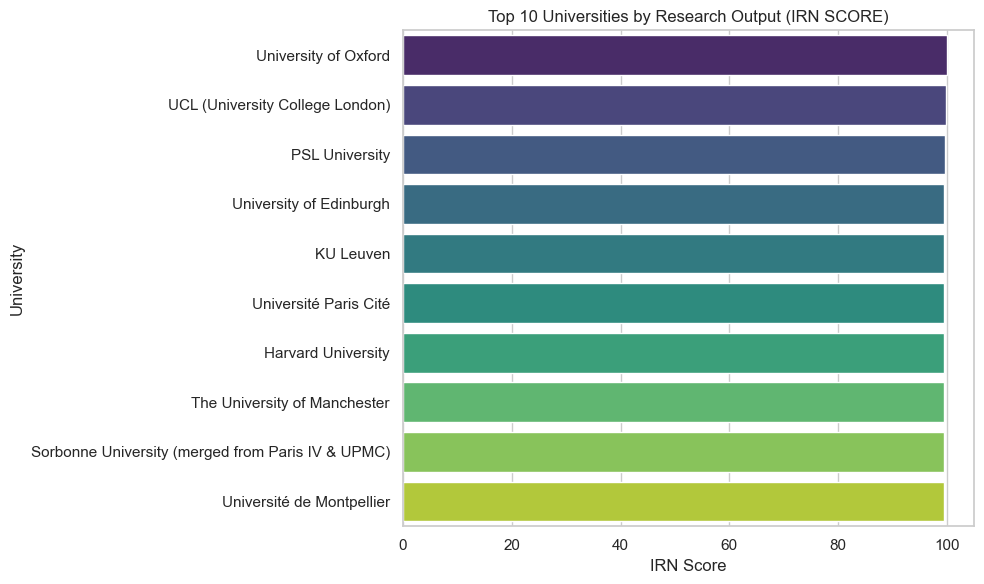

<Figure size 640x480 with 0 Axes>

In [4]:
#Data Visualization

#Top 10 universities by Overall Score
# This plot highlights the best performing universities according to the QS 2026 rankings.
plt.figure(figsize=(10, 6))
top10 = df.sort_values("2026 Rank").head(10)
sns.barplot(data=top10, y="Institution Name", x="Overall SCORE", palette="viridis")
plt.title("Top 10 Universities by Overall Score (QS 2026)")
plt.tight_layout()
plt.savefig("visuals/top10_universities.png")

# Rank Improvement
#This shows which institutions climbed up the QS rankings the most.
df["Rank Change"] = df["Previous Rank"] - df["2026 Rank"]
improved_unis = df[df["Rank Change"] > 0].sort_values("Rank Change", ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=improved_unis, x="Rank Change", y="Institution Name", palette="YlGnBu")
plt.title("Top 10 Universities with the Biggest Rank Improvement")
plt.xlabel("Rank Improvement")
plt.tight_layout()
plt.savefig("visuals/rank_improvement.png")

# Show a heatmap of how the score metrics are correlated
#Get all score-related columns
score_cols = [col for col in df.columns if "SCORE" in col]
plt.figure(figsize=(12, 8))
sns.heatmap(df[score_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Between QS Score Metrics")
plt.show()
plt.savefig("visuals/correlation_heatmap.png")

# Top 10 Countries by Number of Universities 
top_countries = df['Country/Territory'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(y=top_countries.index, x=top_countries.values, palette="coolwarm")
plt.title("Top 10 Countries by Number of Universities in QS 2026")
plt.xlabel("Number of Universities")
plt.ylabel("Country/Territory")
plt.tight_layout()
plt.savefig("visuals/top_countries.png")

# International Student Ratio (ISR) by Region
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Region", y="ISR SCORE", palette="Set1")
plt.title("International Student Ratio (ISR) by Region")
plt.xlabel("Region")
plt.ylabel("International Student Ratio Score (ISR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("visuals/isr_by_region.png")

# Employment Outcomes vs Overall Score
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="EO SCORE", y="Overall SCORE", hue="Region", palette="Set1", alpha=0.7)
plt.title("Employment Outcomes vs Overall QS Score")
plt.xlabel("Employment Outcome Score (EO)")
plt.ylabel("Overall Score")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("visuals/employment_vs_overall_score.png")

# Boxplot for Employment Outcomes by Research Intensity
# Merging Employment Outcomes with Research Intensity
merged_df = df[['Institution Name', 'Research', 'EO SCORE']].dropna()
merged_df = merged_df[merged_df['EO SCORE'].notna() & merged_df['Research'].notna()]
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=merged_df,
    x='Research',
    y='EO SCORE',
    palette='pastel'
)
plt.title("Employment Outcomes by Research Intensity")
plt.xlabel("Research Level")
plt.ylabel("Employment Outcome Score (EO)")
plt.tight_layout()
plt.show()
plt.savefig("visuals/employment_outcomes_research_intensity.png")

#Top 10 universities by research output
top_research_unis = df.nlargest(10, 'IRN SCORE')[['Institution Name', 'Country/Territory', 'IRN SCORE']]
print("\nTop 10 Universities by Research Output (IRN SCORE):")
print(top_research_unis)    
# Create a bar plot for the top 10 research universities
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_research_unis,
    x='IRN SCORE',
    y='Institution Name',
    palette='viridis'
)
plt.title("Top 10 Universities by Research Output (IRN SCORE)")
plt.xlabel("IRN Score")
plt.ylabel("University")
plt.tight_layout()
plt.show()
plt.savefig("visuals/top_research_universities.png")
